# Tutorial 14: AGN Models and IGM Absorption

This notebook demonstrates two physics modules in **diffsed** that are
critical for broadband SED fitting beyond the local universe:

1. **AGN emission** &mdash; accretion disc + dust torus models at three
   complexity levels (`simple`, `standard`, `kubota_done`).
2. **IGM absorption** &mdash; mean intergalactic medium transmission
   (Inoue et al. 2014) that imprints the Lyman break and
   Gunn&ndash;Peterson trough on high-$z$ galaxy spectra.

We show how these modules work standalone, how they integrate into the
`Model` forward model, and how IGM absorption creates the photometric
dropout signatures used for high-redshift galaxy selection.

In [1]:
import os

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
import numpy as np

from diffsed.models.agn import AGN_MODELS, get_agn_model, unified_agn
from diffsed.models.agn.disc import powerlaw_disc, multicolor_disc
from diffsed.models.agn.torus import simple_torus, two_temperature_torus
from diffsed.models.igm import igm_transmission
from diffsed.models.observation.filters import load_filter
from diffsed import (
    Model, ParamSpec, Uniform, Fixed,
    load_ssp_data, load_filter_set,
)

# -- Plot style --------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.prop_cycle": plt.cycler(
        color=["#2b6ca3", "#d65f27", "#3a9a5b", "#c03d3e",
               "#8b6bba", "#8c564b", "#e377c2", "#7f7f7f"]
    ),
})

# -- Figure output directory -------------------------------------------
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)


def savefig(fig, name, dpi=200):
    path = os.path.join(FIG_DIR, f"14_{name}.png")
    fig.savefig(path, bbox_inches="tight", dpi=dpi)
    print(f"Saved {path}")

## 1. AGN Models: Disc + Torus SEDs

diffsed provides three pre-registered AGN configurations, all combining
an accretion disc (UV/optical) with a dust torus (MIR):

| Model | Disc | Torus | Free params |
|-------|------|-------|-------------|
| `simple` | Power-law + UV cutoff | Single-$T$ modified BB | 3 |
| `standard` | Multi-color Shakura&ndash;Sunyaev | Two-$T$ (hot + warm) | 5&ndash;6 |
| `kubota_done` | Multi-color + BH spin | Two-$T$ clumpy | 8+ |

All return $L_\nu$ in $L_\odot\,\mathrm{Hz}^{-1}$.

Saved figures/14_agn_three_models.png


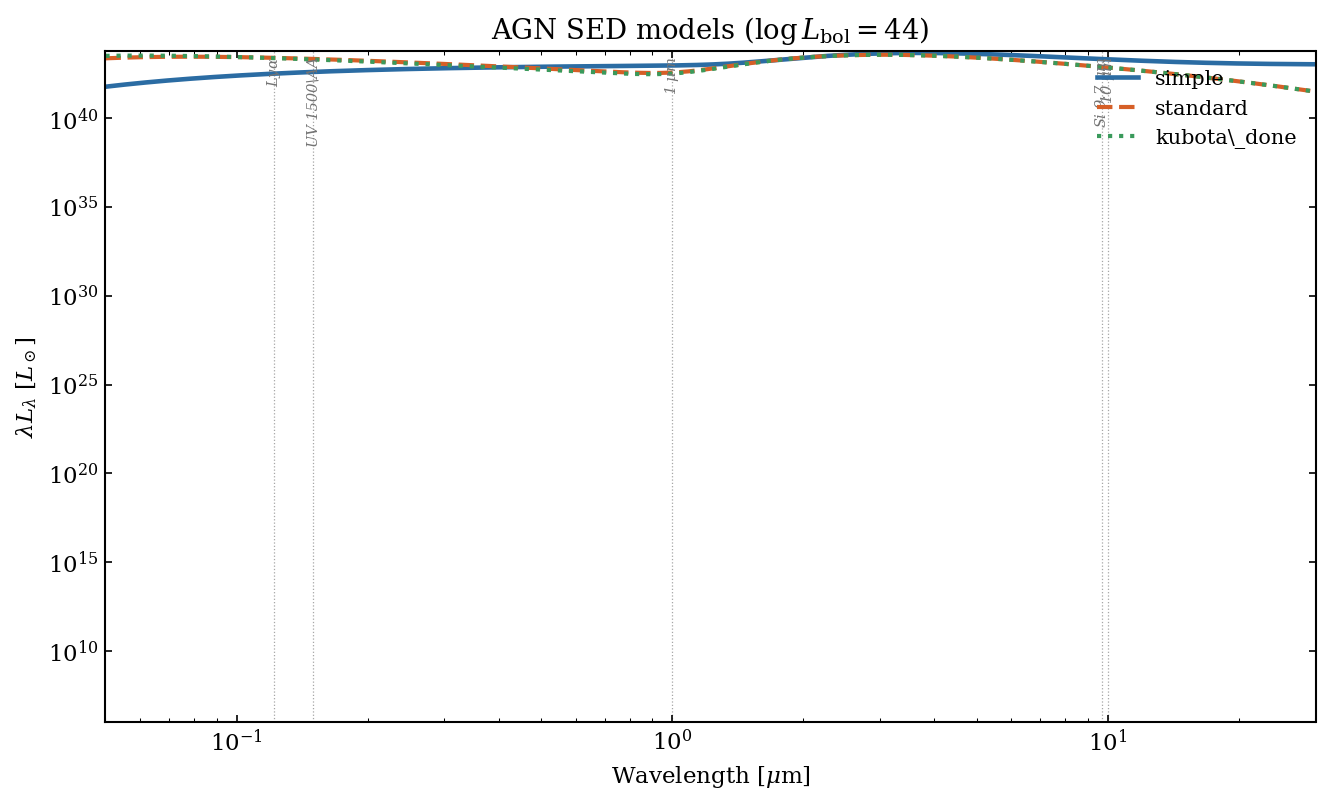

In [2]:
# Wavelength grid: 500 Angstrom to 30 micron (UV to MIR)
wave = jnp.geomspace(500.0, 3e5, 2000)  # Angstrom

# Common parameters
log_lbol = 44.0  # log10(L_bol / Lsun) ~ luminous Seyfert

# --- Compute all three AGN SEDs ---
sed_simple = get_agn_model("simple")(
    wave, agn_log_lbol=log_lbol, agn_lum_ratio=1.0,
    agn_alpha=-1.0, agn_T_torus=1000.0, agn_torus_frac=0.5,
)
sed_standard = get_agn_model("standard")(
    wave, agn_log_lbol=log_lbol, agn_lum_ratio=1.0,
    agn_log_mbh=8.0, agn_log_ledd=-1.0,
    agn_T_hot=1200.0, agn_T_warm=300.0, agn_frac_hot=0.3,
    agn_torus_frac=0.5,
)
sed_kubota = get_agn_model("kubota_done")(
    wave, agn_log_lbol=log_lbol, agn_lum_ratio=1.0,
    agn_log_mbh=8.0, agn_log_ledd=-1.0,
    agn_a_spin=0.5, agn_cos_inc=0.5,
    agn_T_hot=1200.0, agn_T_warm=300.0, agn_frac_hot=0.3,
    agn_tau_torus=5.0, agn_torus_frac=0.5,
)

# Convert to numpy for plotting
wave_um = np.array(wave) / 1e4  # Angstrom -> micron
nu = 2.99792458e18 / np.array(wave)  # Hz

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.loglog(wave_um, np.array(sed_simple) * nu, label="simple", lw=2.2, color="#2b6ca3")
ax.loglog(wave_um, np.array(sed_standard) * nu, label="standard", lw=2.0,
          ls="--", color="#d65f27")
ax.loglog(wave_um, np.array(sed_kubota) * nu, label="kubota\\_done", lw=2.0,
          ls=":", color="#3a9a5b")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$\lambda L_\lambda$ [$L_\odot$]")
ax.set_title(r"AGN SED models ($\log L_{\rm bol} = 44$)")
ax.set_xlim(0.05, 30)
ax.set_ylim(bottom=1e6)
ax.legend(loc="upper right", fontsize=10)

# Key wavelength annotations
key_lines = {
    r"Ly$\alpha$": 0.1216e-4 * 1e4,  # 0.1216 um
    r"UV 1500\AA": 0.15,
    r"1 $\mu$m": 1.0,
    r"10 $\mu$m": 10.0,
    r"Si 9.7 $\mu$m": 9.7,
}
ylim_top = ax.get_ylim()[1]
for label, lam_um in key_lines.items():
    ax.axvline(lam_um, color="0.65", ls=":", lw=0.6, zorder=0)
    ax.text(lam_um, ylim_top * 0.5, label, fontsize=7, color="0.45",
            ha="center", va="top", rotation=90, style="italic")

fig.tight_layout()
savefig(fig, "agn_three_models")
plt.show()

### 1b. Disc vs Torus Components

The `unified_agn` combiner splits the bolometric luminosity between the
disc (fraction $1 - f_{\rm torus}$) and the torus ($f_{\rm torus}$).
Here we show the two components separately for the `simple` model,
displayed as filled regions to visualize the energy budget.

<>:37: SyntaxWarning: invalid escape sequence '\A'
<>:37: SyntaxWarning: invalid escape sequence '\A'
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_10885/1218910379.py:37: SyntaxWarning: invalid escape sequence '\A'
  for label, lam_um in {r"Ly$\alpha$": 0.1216, "UV 1500 \AA": 0.15,


Saved figures/14_disc_torus_decomposition.png


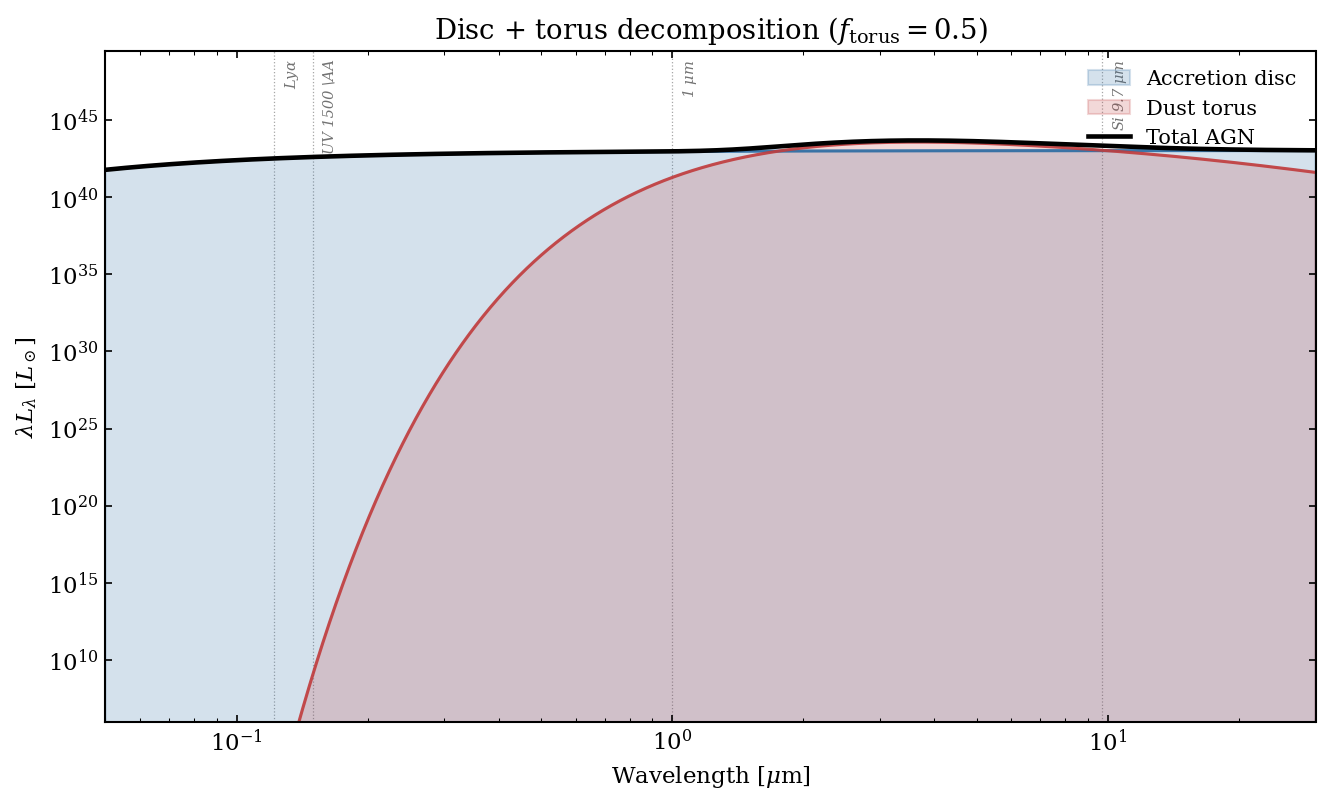

In [3]:
torus_frac = 0.5

# Disc only (power-law)
l_disc = powerlaw_disc(wave, agn_log_lbol=log_lbol, agn_lum_ratio=1.0 - torus_frac,
                       agn_alpha=-1.0)
# Torus only (single-T)
l_torus = simple_torus(wave, agn_log_lbol=log_lbol, agn_torus_frac=torus_frac,
                       agn_T_torus=1000.0)
l_total = l_disc + l_torus

# Convert to lambda*L_lambda
disc_lLl = np.array(l_disc) * nu
torus_lLl = np.array(l_torus) * nu
total_lLl = np.array(l_total) * nu

fig, ax = plt.subplots(figsize=(9, 5.5))

# Filled regions showing energy budget
ax.fill_between(wave_um, 1e-10, disc_lLl, alpha=0.20, color="#2b6ca3",
                label="Accretion disc")
ax.fill_between(wave_um, 1e-10, torus_lLl, alpha=0.20, color="#c03d3e",
                label="Dust torus")

# Line on top
ax.loglog(wave_um, disc_lLl, color="#2b6ca3", lw=1.5, alpha=0.9)
ax.loglog(wave_um, torus_lLl, color="#c03d3e", lw=1.5, alpha=0.9)
ax.loglog(wave_um, total_lLl, color="k", lw=2.2, label="Total AGN")

ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$\lambda L_\lambda$ [$L_\odot$]")
ax.set_title(r"Disc + torus decomposition ($f_{\rm torus} = 0.5$)")
ax.set_xlim(0.05, 30)
ax.set_ylim(bottom=1e6)
ax.legend(loc="upper right", fontsize=10)

# Mark key wavelengths
for label, lam_um in {r"Ly$\alpha$": 0.1216, "UV 1500 \AA": 0.15,
                       r"1 $\mu$m": 1.0, r"Si 9.7 $\mu$m": 9.7}.items():
    ax.axvline(lam_um, color="0.65", ls=":", lw=0.6, zorder=0)
    ax.text(lam_um * 1.05, ax.get_ylim()[1] * 0.3, label, fontsize=7,
            color="0.45", rotation=90, va="top", style="italic")

fig.tight_layout()
savefig(fig, "disc_torus_decomposition")
plt.show()

### 1c. Effect of AGN Fraction on the Total SED

The `agn_lum_ratio` parameter controls what fraction of the total bolometric
luminosity comes from the AGN. At low fractions the galaxy SED dominates;
at high fractions the UV and MIR are boosted by the disc and torus.

Saved figures/14_agn_frac_effect.png


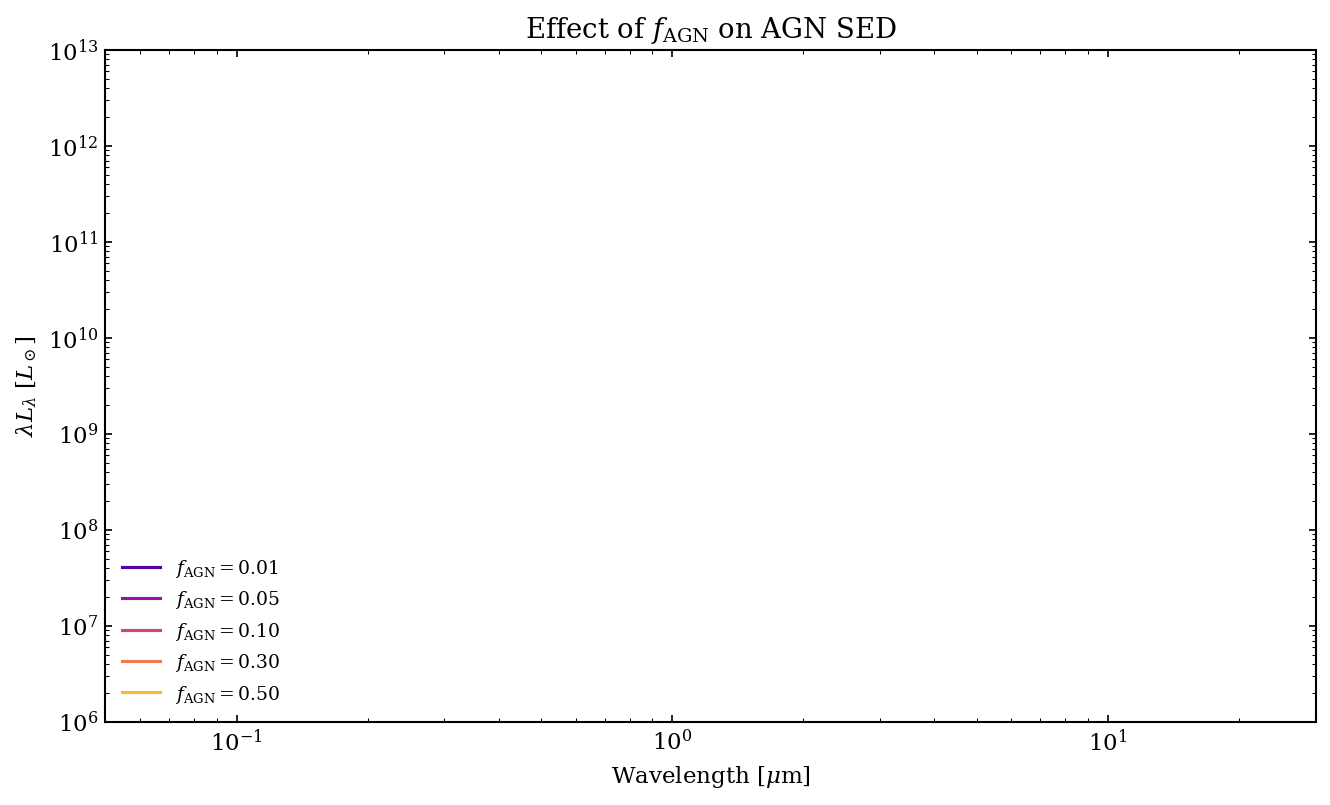

In [4]:
agn_fracs = [0.01, 0.05, 0.1, 0.3, 0.5]
colors_frac = plt.cm.plasma(np.linspace(0.15, 0.85, len(agn_fracs)))

fig, ax = plt.subplots(figsize=(9, 5.5))
for frac, col in zip(agn_fracs, colors_frac):
    sed_frac = get_agn_model("simple")(
        wave, agn_log_lbol=log_lbol, agn_lum_ratio=frac,
        agn_alpha=-1.0, agn_T_torus=1000.0, agn_torus_frac=0.5,
    )
    ax.loglog(wave_um, np.array(sed_frac) * nu, color=col,
              label=f"$f_{{\\rm AGN}} = {frac:.2f}$", lw=1.5)

ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$\lambda L_\lambda$ [$L_\odot$]")
ax.set_title(r"Effect of $f_{\rm AGN}$ on AGN SED")
ax.set_xlim(0.05, 30)
ax.set_ylim(1e6, 1e13)
ax.legend(loc="lower left", fontsize=9)
fig.tight_layout()
savefig(fig, "agn_frac_effect")
plt.show()

## 2. AGN in the Forward Model

When `agn_model="simple"` is set in the `ParamSpec`, the `Model` class
automatically adds AGN emission to the stellar SED. The AGN bolometric
luminosity is computed as `agn_lum_ratio * L_bol_stellar`, so the same
parameter controls the relative AGN contribution at all wavelengths.

Here we compare a galaxy SED with and without AGN using
GALEX + SDSS + WISE filters.

In [5]:
# Load SSP data
ssp_data = load_ssp_data("../data/fsps_prsc_miles_chabrier.h5")

# Filter set: GALEX (UV) + SDSS (optical) + WISE (MIR)
filter_names = [
    "galex_fuv", "galex_nuv",
    "sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z",
    "wise_w1", "wise_w2", "wise_w3", "wise_w4",
]
filters = load_filter_set(filter_names)
filter_wave_eff = np.array([
    1528, 2271,  # GALEX
    3551, 4686, 6166, 7480, 8932,  # SDSS
    33526, 46028, 115608, 220883,  # WISE
])

# --- Galaxy WITHOUT AGN ---
spec_no_agn = ParamSpec(
    sfh_dpl_log_peak_sfr=Fixed(1.0),
    sfh_dpl_tau_gyr=Fixed(5.0),
    sfh_dpl_alpha=Fixed(1.5),
    sfh_dpl_beta=Fixed(2.0),
    met_logzsol=Fixed(-0.2),
    dust_tau_bc=Fixed(0.3),
    dust_tau_diff=Fixed(0.6),
    redshift=Fixed(0.1),
    mean_sfh_type="dpl",
    apply_igm=False,
)
model_no_agn = Model(spec_no_agn, ssp_data, filters=filters)

# --- Galaxy WITH AGN (simple model, 10% AGN fraction) ---
spec_agn = ParamSpec(
    sfh_dpl_log_peak_sfr=Fixed(1.0),
    sfh_dpl_tau_gyr=Fixed(5.0),
    sfh_dpl_alpha=Fixed(1.5),
    sfh_dpl_beta=Fixed(2.0),
    met_logzsol=Fixed(-0.2),
    dust_tau_bc=Fixed(0.3),
    dust_tau_diff=Fixed(0.6),
    agn_lum_ratio=Fixed(0.1),
    agn_alpha=Fixed(-1.0),
    agn_T_torus=Fixed(1000.0),
    redshift=Fixed(0.1),
    mean_sfh_type="dpl",
    agn_model="simple",
    apply_igm=False,
)
model_agn = Model(spec_agn, ssp_data, filters=filters)

# Sample at the fixed values
params_no_agn = spec_no_agn.sample(jax.random.PRNGKey(0))
params_agn = spec_agn.sample(jax.random.PRNGKey(0))

# Compute photometry
phot_no_agn = np.array(model_no_agn.predict_photometry(params_no_agn))
phot_agn = np.array(model_agn.predict_photometry(params_agn))

# Compute rest-frame SEDs for context
sed_no_agn = np.array(model_no_agn.predict_sed(params_no_agn))
sed_agn = np.array(model_agn.predict_sed(params_agn))
ssp_wave_um = np.array(ssp_data.ssp_wave) / 1e4  # Angstrom -> micron

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_10885/3485794794.py:30: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC). Set approx=False to disable.
  model_no_agn = Model(spec_no_agn, ssp_data, filters=filters)
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_10885/3485794794.py:49: UserWarning: Fused kernel disabled, using exact path (slower). Reasons: AGN (legacy agn_lum_ratio mode) requires full SED for bolometric luminosity. Set approx=True or remove incompatible components for ~10-50x speedup.
  model_agn = Model(spec_agn, ssp_data, filters=filters)


Saved figures/14_agn_forward_model.png


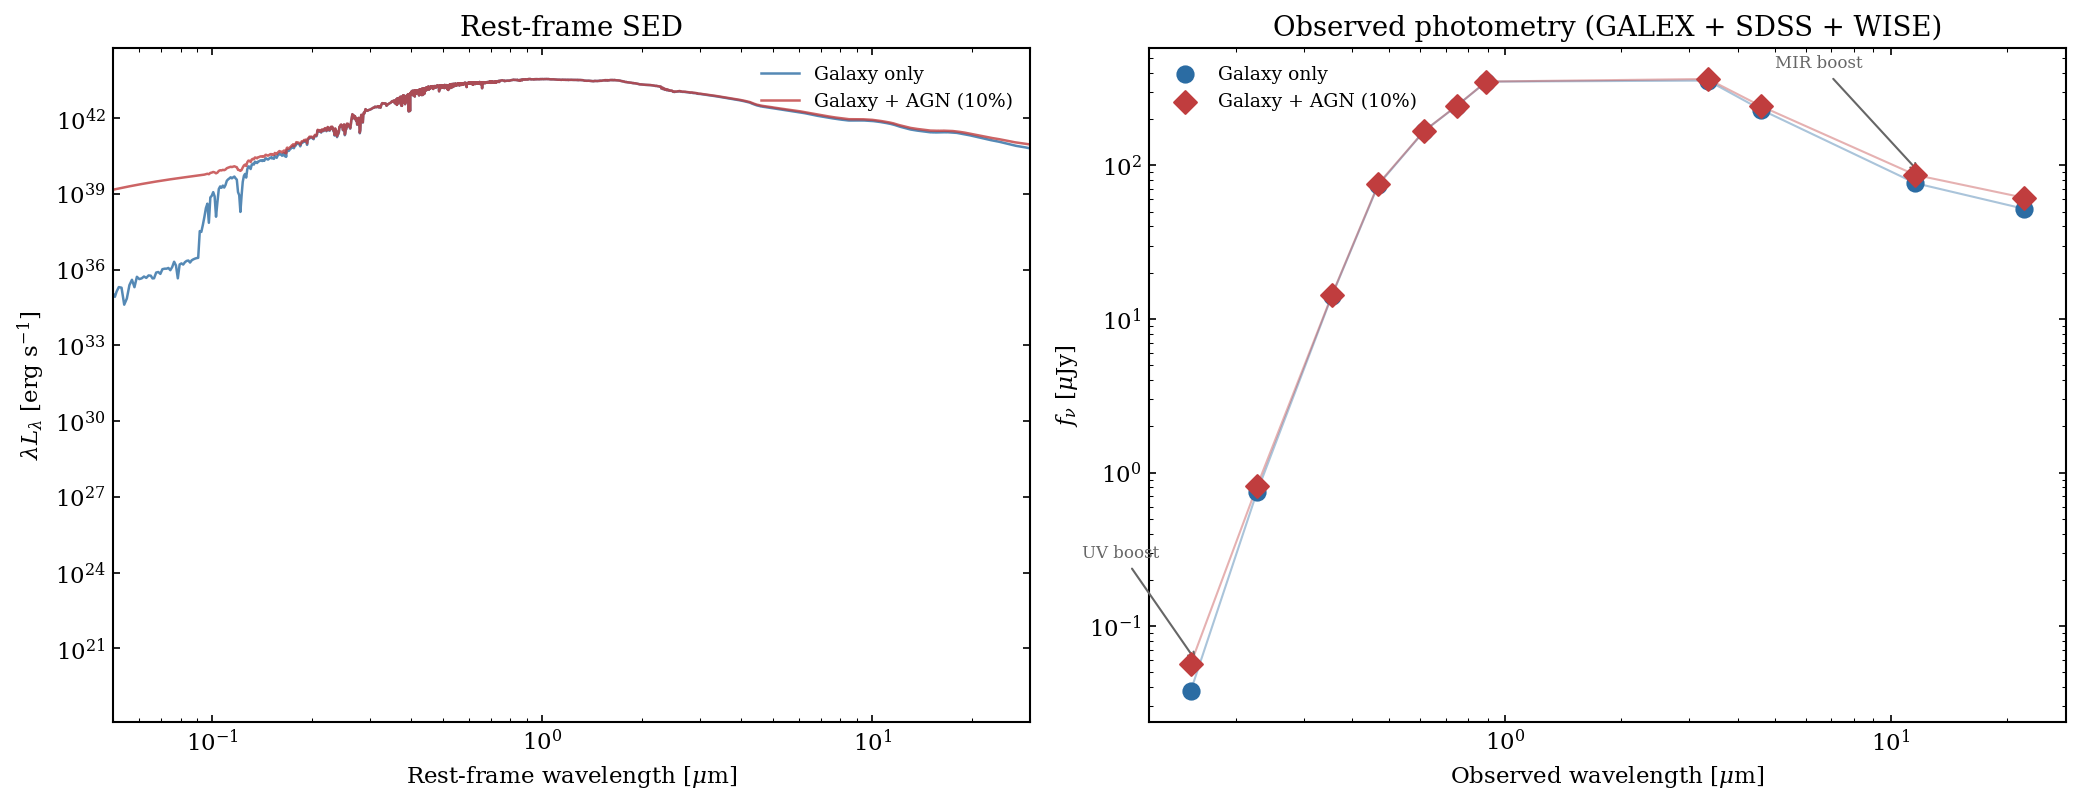

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Left panel: rest-frame SEDs ---
nu_ssp = 2.99792458e18 / np.array(ssp_data.ssp_wave)
ax1.loglog(ssp_wave_um, sed_no_agn * nu_ssp, color="#2b6ca3", lw=1.2,
           label="Galaxy only", alpha=0.8)
ax1.loglog(ssp_wave_um, sed_agn * nu_ssp, color="#c03d3e", lw=1.2,
           label="Galaxy + AGN (10%)", alpha=0.8)
ax1.set_xlabel(r"Rest-frame wavelength [$\mu$m]")
ax1.set_ylabel(r"$\lambda L_\lambda$ [erg s$^{-1}$]")
ax1.set_title("Rest-frame SED")
ax1.set_xlim(0.05, 30)
ax1.legend(loc="upper right")

# --- Right panel: observed photometry ---
ax2.scatter(filter_wave_eff / 1e4, phot_no_agn * 1e29, s=60, marker="o",
            color="#2b6ca3", zorder=5, label="Galaxy only")
ax2.scatter(filter_wave_eff / 1e4, phot_agn * 1e29, s=60, marker="D",
            color="#c03d3e", zorder=5, label="Galaxy + AGN (10%)")
# Connect with lines for clarity
ax2.plot(filter_wave_eff / 1e4, phot_no_agn * 1e29, "-", color="#2b6ca3",
         alpha=0.4, lw=1.0)
ax2.plot(filter_wave_eff / 1e4, phot_agn * 1e29, "-", color="#c03d3e",
         alpha=0.4, lw=1.0)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"Observed wavelength [$\mu$m]")
ax2.set_ylabel(r"$f_\nu$ [$\mu$Jy]")
ax2.set_title("Observed photometry (GALEX + SDSS + WISE)")
ax2.legend(loc="upper left")

# Annotate UV and MIR boost
ax2.annotate("UV boost", xy=(0.16, phot_agn[0] * 1e29),
             xytext=(0.08, phot_agn[0] * 1e29 * 5),
             arrowprops=dict(arrowstyle="->", color="0.4"),
             fontsize=8, color="0.4")
ax2.annotate("MIR boost", xy=(12, phot_agn[-2] * 1e29),
             xytext=(5, phot_agn[-2] * 1e29 * 5),
             arrowprops=dict(arrowstyle="->", color="0.4"),
             fontsize=8, color="0.4")

fig.tight_layout()
savefig(fig, "agn_forward_model")
plt.show()

## 3. IGM Transmission

The intergalactic medium absorbs photons blueward of Lyman-$\alpha$
(1216 \AA) through:

- **Lyman-series line absorption** (Ly$\alpha$ forest + DLA systems)
- **Lyman-continuum absorption** ($\lambda < 912$ \AA)

diffsed implements the Inoue et al. (2014) mean IGM transmission
$T_{\rm IGM}(\lambda_{\rm obs}, z_{\rm source})$, which is a
function of observed wavelength and source redshift.

Saved figures/14_igm_transmission.png


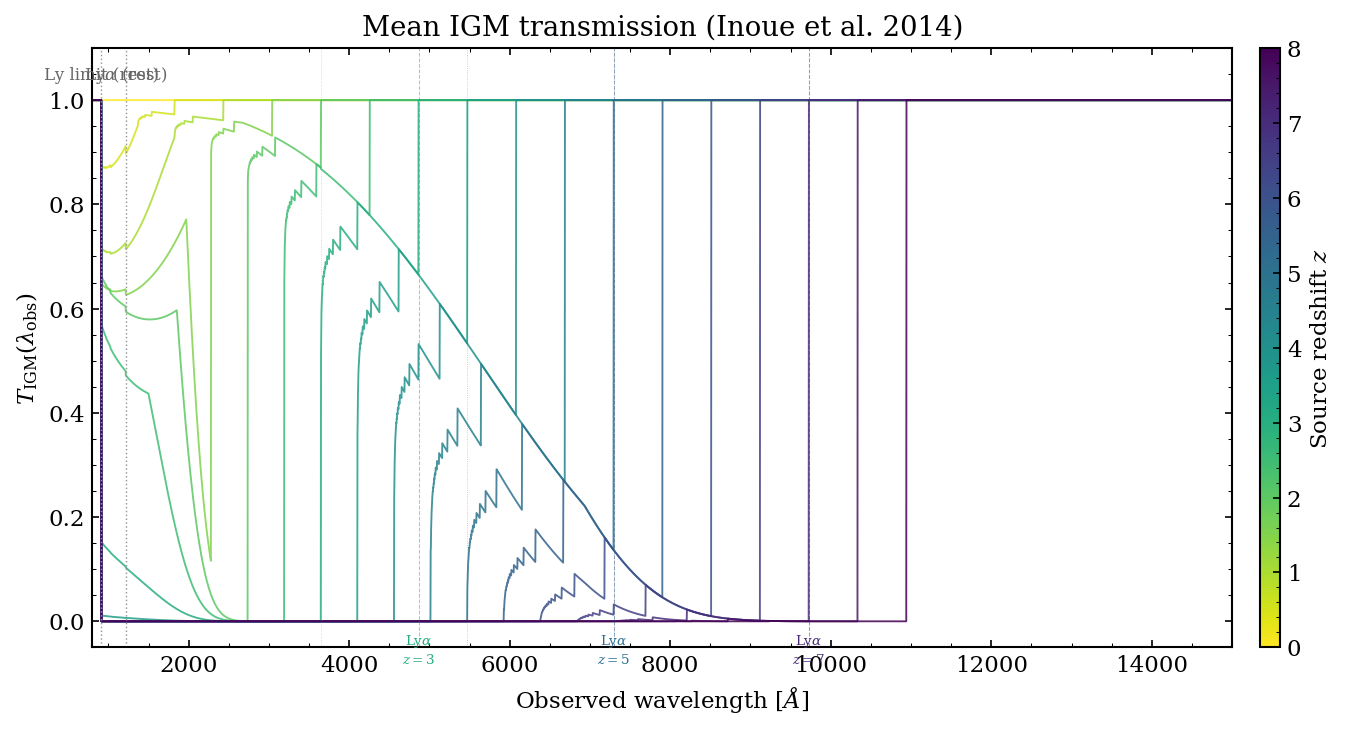

In [7]:
# Observed wavelength grid
wave_obs = jnp.linspace(800.0, 15000.0, 5000)
wave_obs_np = np.array(wave_obs)

# Compute T_IGM at a dense redshift grid for colormap display
z_vals = np.arange(0.0, 8.5, 0.5)
n_z = len(z_vals)

# Use a smooth colormap with a colorbar
cmap = plt.cm.viridis_r
norm = mcolors.Normalize(vmin=0, vmax=8)

fig, ax = plt.subplots(figsize=(10, 5))

for z_s in z_vals:
    t_igm = np.array(igm_transmission(wave_obs, z_s))
    ax.plot(wave_obs_np, t_igm, color=cmap(norm(z_s)), lw=0.9, alpha=0.85)

# Colorbar for redshift
sm = mcm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=30)
cbar.set_label(r"Source redshift $z$", fontsize=11)
cbar.set_ticks(np.arange(0, 9, 1))

# Mark Ly-alpha and Ly-limit at rest frame
ax.axvline(1216.0, color="0.6", ls=":", lw=0.7)
ax.text(1216, 1.04, r"Ly$\alpha$ (rest)", fontsize=8, ha="center", color="0.4")
ax.axvline(912.0, color="0.6", ls=":", lw=0.7)
ax.text(912, 1.04, r"Ly limit (rest)", fontsize=8, ha="center", color="0.4")

# Mark Ly-alpha at selected redshifts
for z_mark in [3, 5, 7]:
    lam_lya = 1216.0 * (1.0 + z_mark)
    ax.axvline(lam_lya, color=cmap(norm(z_mark)), ls="--", lw=0.5, alpha=0.5)
    ax.text(lam_lya, -0.08, f"Ly$\\alpha$\n$z={z_mark}$", fontsize=6.5,
            ha="center", color=cmap(norm(z_mark)), clip_on=False)
    lam_lylim = 912.0 * (1.0 + z_mark)
    ax.axvline(lam_lylim, color=cmap(norm(z_mark)), ls=":", lw=0.4, alpha=0.4)

ax.set_ylabel(r"$T_{\rm IGM}(\lambda_{\rm obs})$")
ax.set_xlabel(r"Observed wavelength [$\AA$]")
ax.set_ylim(-0.05, 1.1)
ax.set_xlim(800, 15000)
ax.set_title("Mean IGM transmission (Inoue et al. 2014)")

fig.tight_layout()
savefig(fig, "igm_transmission")
plt.show()

### 3b. IGM Transmission Detail: Lyman Series at $z = 4$

Zoom into the Lyman break region at $z = 4$ to show the individual
Lyman-series absorption features and the Gunn-Peterson trough.

Saved figures/14_igm_lyman_series_z4.png


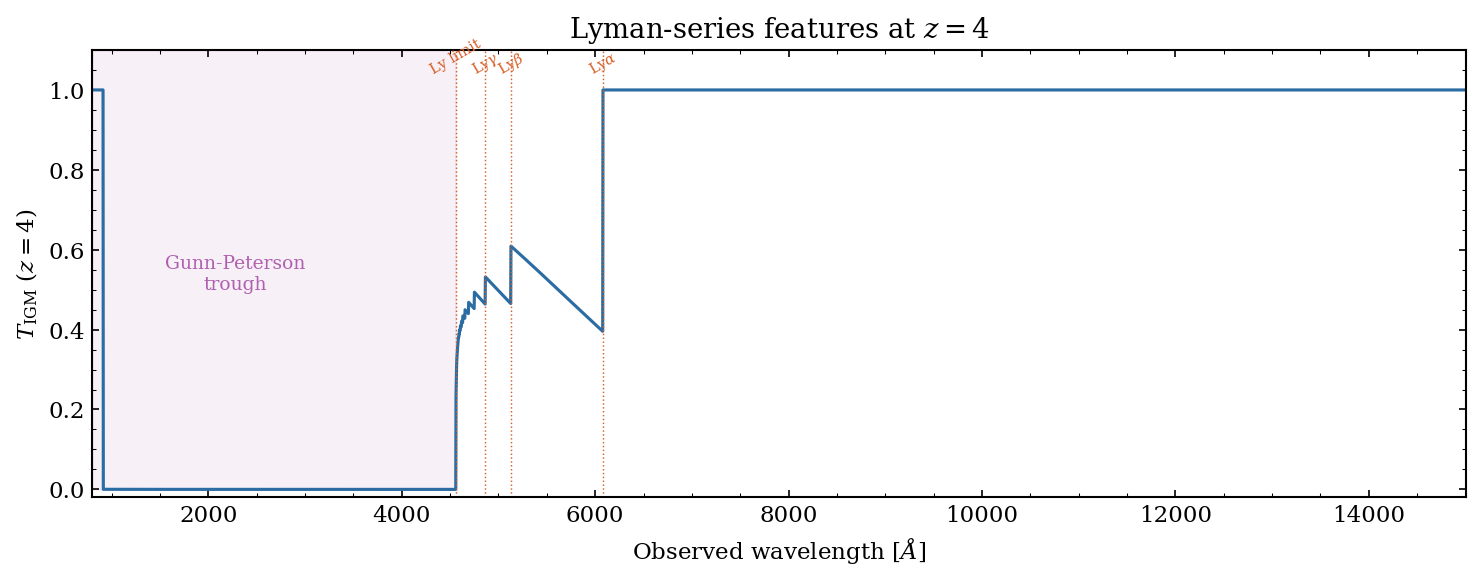

In [8]:
t_z4 = np.array(igm_transmission(wave_obs, 4.0))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wave_obs_np, t_z4, color="#2b6ca3", lw=1.5)
ax.set_ylabel(r"$T_{\rm IGM}$ ($z=4$)")
ax.set_xlabel(r"Observed wavelength [$\AA$]")
ax.set_ylim(-0.02, 1.1)
ax.set_xlim(800, 15000)

# Mark Lyman series lines shifted to z=4
lyman_lines = {"Ly$\\alpha$": 1216.0, "Ly$\\beta$": 1026.0,
               "Ly$\\gamma$": 973.0, "Ly limit": 912.0}
for name, lam_rest in lyman_lines.items():
    lam_obs = lam_rest * (1.0 + 4.0)
    ax.axvline(lam_obs, color="#d65f27", ls=":", lw=0.7)
    ax.text(lam_obs, 1.04, name, fontsize=7, ha="center",
            color="#d65f27", rotation=30)

# Shade Gunn-Peterson trough region
mask_gp = wave_obs_np < 912.0 * (1.0 + 4.0)
ax.fill_between(wave_obs_np[mask_gp], 0, 1.1, alpha=0.06, color="purple")
ax.text(912.0 * 5.0 / 2, 0.5, "Gunn-Peterson\ntrough", fontsize=9,
        ha="center", color="purple", alpha=0.6)

ax.set_title(r"Lyman-series features at $z = 4$")
fig.tight_layout()
savefig(fig, "igm_lyman_series_z4")
plt.show()

## 4. High-$z$ Galaxy with IGM: Dropout Signature

At $z = 6$, the Lyman break at 912 \AA\ is redshifted to
$\sim 6400$ \AA\ (observed), while Ly$\alpha$ at 1216 \AA\ shifts to
$\sim 8500$ \AA. This means essentially all flux blueward of the
$i$-band is absorbed, creating a classic "$i$-band dropout."

We show the galaxy SED at $z = 6$ with IGM ON and OFF, overlaid with
JWST NIRCam filter transmission curves.

In [9]:
# JWST NIRCam wide-band filter names
jwst_names = [
    "jwst_f090w", "jwst_f115w", "jwst_f150w", "jwst_f200w",
    "jwst_f277w", "jwst_f356w", "jwst_f444w",
]
jwst_labels = ["F090W", "F115W", "F150W", "F200W", "F277W", "F356W", "F444W"]

# Load filter curves (for transmission overlays)
jwst_curves = [load_filter(n) for n in jwst_names]

# Also load as filter set for Model
jwst_filters = load_filter_set(jwst_names)
# Approximate effective wavelengths (micron)
jwst_wave_eff_um = np.array([0.90, 1.15, 1.50, 2.00, 2.77, 3.56, 4.44])

# ParamSpec for a z=6 star-forming galaxy
spec_z6 = ParamSpec(
    sfh_dpl_log_peak_sfr=Fixed(1.5),
    sfh_dpl_tau_gyr=Fixed(0.3),
    sfh_dpl_alpha=Fixed(1.0),
    sfh_dpl_beta=Fixed(5.0),
    met_logzsol=Fixed(-1.0),
    dust_tau_bc=Fixed(0.05),
    dust_tau_diff=Fixed(0.1),
    redshift=Fixed(6.0),
    mean_sfh_type="dpl",
    apply_igm=True,
)
spec_z6_noigm = ParamSpec(
    sfh_dpl_log_peak_sfr=Fixed(1.5),
    sfh_dpl_tau_gyr=Fixed(0.3),
    sfh_dpl_alpha=Fixed(1.0),
    sfh_dpl_beta=Fixed(5.0),
    met_logzsol=Fixed(-1.0),
    dust_tau_bc=Fixed(0.05),
    dust_tau_diff=Fixed(0.1),
    redshift=Fixed(6.0),
    mean_sfh_type="dpl",
    apply_igm=False,
)

model_z6 = Model(spec_z6, ssp_data, filters=jwst_filters)
model_z6_noigm = Model(spec_z6_noigm, ssp_data, filters=jwst_filters)

params_z6 = spec_z6.sample(jax.random.PRNGKey(42))
params_z6_noigm = spec_z6_noigm.sample(jax.random.PRNGKey(42))

phot_z6 = np.array(model_z6.predict_photometry(params_z6))
phot_z6_noigm = np.array(model_z6_noigm.predict_photometry(params_z6_noigm))

# Also get SEDs for continuous curve
sed_z6_rest = np.array(model_z6.predict_sed(params_z6))
sed_z6_noigm_rest = np.array(model_z6_noigm.predict_sed(params_z6_noigm))
ssp_wave_obs_um = np.array(ssp_data.ssp_wave) * (1.0 + 6.0) / 1e4  # observed micron

# Convert SEDs to approximate observed flux (erg/s/cm2/Hz -> uJy)
# Scale factor: use photometry to anchor the SED normalization
# For display, we normalize SED to match photometry at F200W
sed_scale_idx = np.argmin(np.abs(ssp_wave_obs_um - 2.0))  # near F200W
if sed_z6_noigm_rest[sed_scale_idx] > 0:
    # F200W is index 3 in our filter list
    sed_norm = (phot_z6_noigm[3] * 1e29) / (sed_z6_noigm_rest[sed_scale_idx] * 1e29 /
               np.max(sed_z6_noigm_rest * 1e29) * np.max(phot_z6_noigm * 1e29))
else:
    sed_norm = 1.0

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_10885/580554032.py:42: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_z6 = Model(spec_z6, ssp_data, filters=jwst_filters)
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_10885/580554032.py:43: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC). Set approx=False to disable.
  model_z6_noigm = Model(spec_z6_noigm, ssp_data, filters=jwst_filters)


Saved figures/14_high_z_galaxy_igm.png


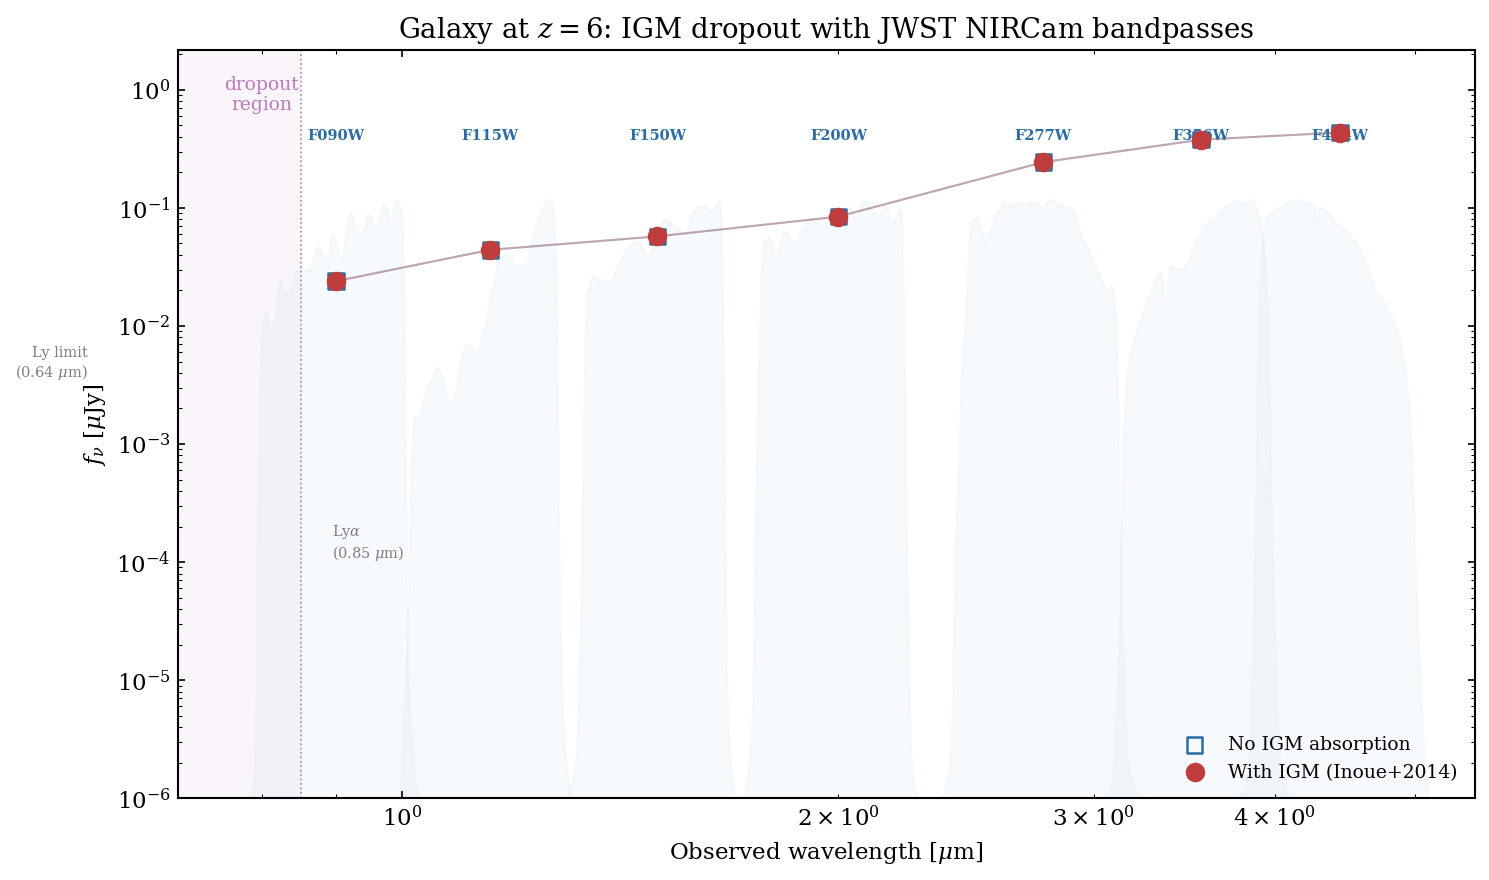

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

# Convert to uJy
phot_uJy = phot_z6 * 1e29
phot_uJy_noigm = phot_z6_noigm * 1e29

# -- Shaded JWST filter bandpasses --
filter_colors = ["#b0b0b0", "#a0a0a0", "#909090", "#808080",
                 "#707070", "#606060", "#505050"]
# Determine which bands are dropouts (Ly-alpha at z=6 = 8512 A = 0.85 um)
lam_lya_obs_um = 1216.0 * 7.0 / 1e4  # 0.8512 um

for i, (fc, label) in enumerate(zip(jwst_curves, jwst_labels)):
    fw = np.array(fc.wave) / 1e4  # Angstrom -> micron
    ft = np.array(fc.trans)

    # Color dropout bands differently
    eff_wave = jwst_wave_eff_um[i]
    is_dropout = eff_wave < lam_lya_obs_um
    fill_color = "#e8c0c0" if is_dropout else "#c0d8e8"
    edge_color = "#c03d3e" if is_dropout else "#2b6ca3"

    # Plot normalized transmission on a secondary (invisible) scale
    ax.fill_between(fw, 0, ft * 0.8, alpha=0.12, color=fill_color,
                    zorder=1, transform=ax.get_xaxis_transform())
    ax.text(eff_wave, 0.88, label, fontsize=7, ha="center", color=edge_color,
            fontweight="bold", transform=ax.get_xaxis_transform())

# -- Photometry points --
# No IGM (open squares)
ax.scatter(jwst_wave_eff_um, phot_uJy_noigm, s=55, marker="s",
           facecolors="none", edgecolors="#2b6ca3", linewidths=1.2,
           zorder=5, label="No IGM absorption")
ax.plot(jwst_wave_eff_um, phot_uJy_noigm, "-", color="#2b6ca3",
        alpha=0.3, lw=1.0)

# With IGM (filled circles)
ax.scatter(jwst_wave_eff_um, np.maximum(phot_uJy, 1e-10), s=70,
           marker="o", color="#c03d3e", zorder=6, label="With IGM (Inoue+2014)")
ax.plot(jwst_wave_eff_um, np.maximum(phot_uJy, 1e-10), "-",
        color="#c03d3e", alpha=0.3, lw=1.0)

# Mark the Lyman break and Ly-alpha at z=6
lam_ly_obs = 912.0 * 7.0 / 1e4  # micron
ax.axvline(lam_ly_obs, color="0.6", ls="--", lw=0.8)
ax.text(lam_ly_obs * 0.95, ax.get_ylim()[0] if ax.get_ylim()[0] > 1e-6 else 1e-6,
        f"Ly limit\n({lam_ly_obs:.2f} $\\mu$m)", fontsize=7, ha="right",
        color="0.5", va="bottom")
ax.axvline(lam_lya_obs_um, color="0.6", ls=":", lw=0.8)
ax.text(lam_lya_obs_um * 1.05, 1e-4, f"Ly$\\alpha$\n({lam_lya_obs_um:.2f} $\\mu$m)",
        fontsize=7, ha="left", color="0.5", va="bottom")

# Shade dropout region
ax.axvspan(0.7, lam_lya_obs_um, alpha=0.04, color="purple", zorder=0)
ax.text(0.8, 0.92, "dropout\nregion", fontsize=9, ha="center", color="purple",
        alpha=0.5, transform=ax.get_xaxis_transform())

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Observed wavelength [$\mu$m]")
ax.set_ylabel(r"$f_\nu$ [$\mu$Jy]")
ax.set_title(r"Galaxy at $z = 6$: IGM dropout with JWST NIRCam bandpasses")
ax.set_xlim(0.7, 5.5)
ax.set_ylim(1e-6, phot_uJy_noigm.max() * 5)
ax.legend(loc="lower right", fontsize=9)

fig.tight_layout()
savefig(fig, "high_z_galaxy_igm")
plt.show()

## 5. Dropout Signature Across Redshifts

The power of IGM absorption for photometric redshift estimation comes
from the fact that the Lyman break moves through the filter set as
redshift increases. At $z \sim 4$ it falls in the $u$-band
("$u$-dropout"), at $z \sim 5$ in the $g$-band, at $z \sim 6$ in
the $r$-band, and at $z \sim 7$ in the $i$-band.

Here we show observed photometry of the same intrinsic galaxy at
$z = 4, 5, 6, 7$ through JWST NIRCam filters, with filter
transmission curves overlaid.

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_10885/2009256028.py:33: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_z = Model(spec_z, ssp_data, filters=jwst_filters)
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_10885/2009256028.py:34: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC). Set approx=False to disable.
  model_z_noigm = Model(spec_z_noigm, ssp_data, filters=jwst_filters)


Saved figures/14_dropout_signature_jwst.png


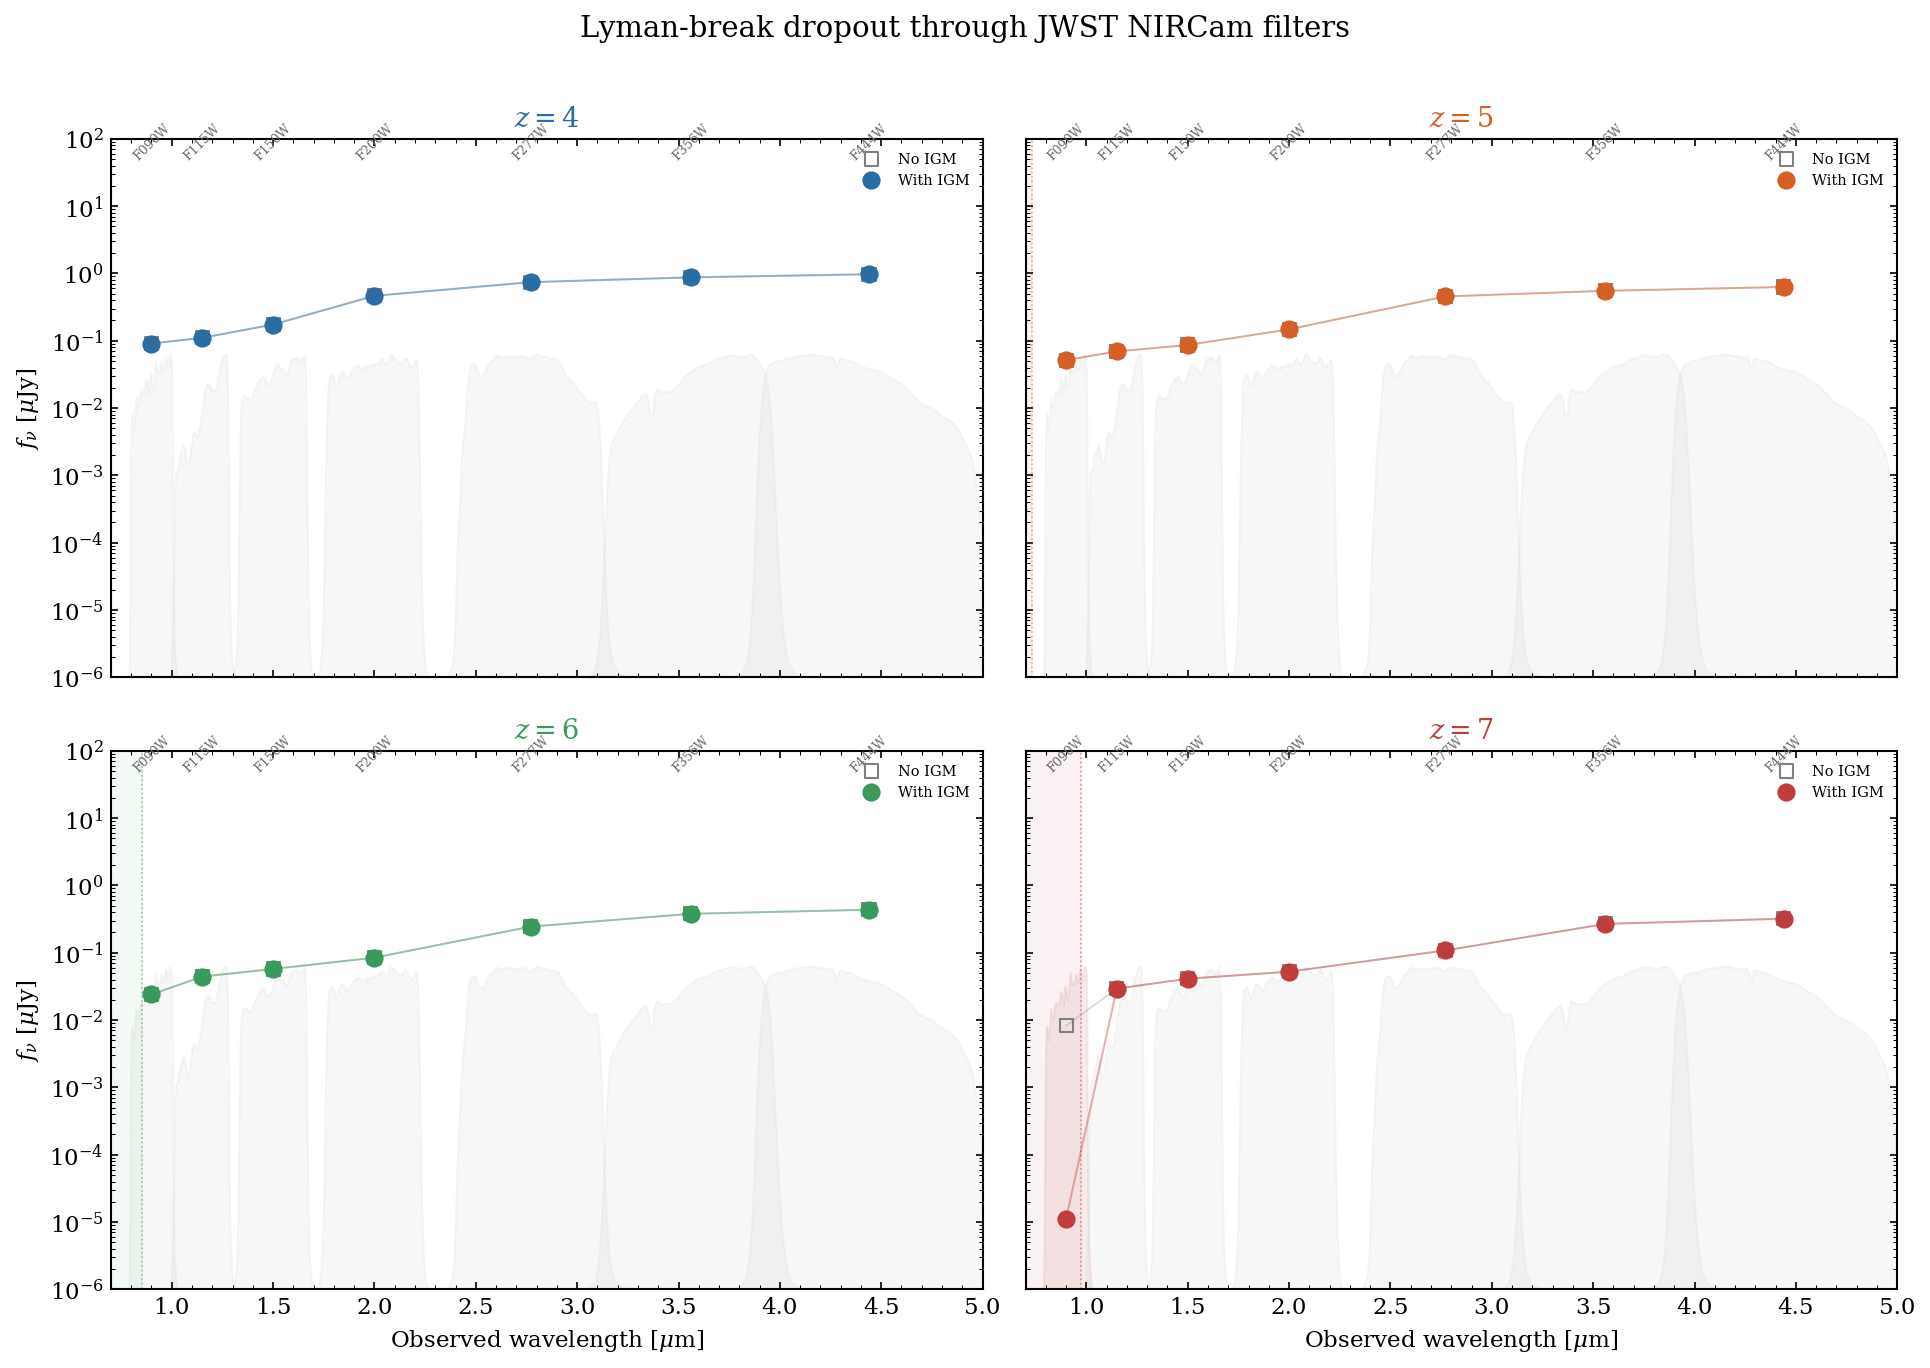

In [11]:
target_redshifts = [4.0, 5.0, 6.0, 7.0]
panel_colors = ["#2b6ca3", "#d65f27", "#3a9a5b", "#c03d3e"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)

for ax, z_target, col in zip(axes.flat, target_redshifts, panel_colors):
    # Build model at this redshift
    spec_z = ParamSpec(
        sfh_dpl_log_peak_sfr=Fixed(1.5),
        sfh_dpl_tau_gyr=Fixed(0.3),
        sfh_dpl_alpha=Fixed(1.0),
        sfh_dpl_beta=Fixed(5.0),
        met_logzsol=Fixed(-1.0),
        dust_tau_bc=Fixed(0.05),
        dust_tau_diff=Fixed(0.1),
        redshift=Fixed(z_target),
        mean_sfh_type="dpl",
        apply_igm=True,
    )
    spec_z_noigm = ParamSpec(
        sfh_dpl_log_peak_sfr=Fixed(1.5),
        sfh_dpl_tau_gyr=Fixed(0.3),
        sfh_dpl_alpha=Fixed(1.0),
        sfh_dpl_beta=Fixed(5.0),
        met_logzsol=Fixed(-1.0),
        dust_tau_bc=Fixed(0.05),
        dust_tau_diff=Fixed(0.1),
        redshift=Fixed(z_target),
        mean_sfh_type="dpl",
        apply_igm=False,
    )

    model_z = Model(spec_z, ssp_data, filters=jwst_filters)
    model_z_noigm = Model(spec_z_noigm, ssp_data, filters=jwst_filters)

    p_z = spec_z.sample(jax.random.PRNGKey(int(z_target * 10)))
    p_z_noigm = spec_z_noigm.sample(jax.random.PRNGKey(int(z_target * 10)))

    phot_igm = np.array(model_z.predict_photometry(p_z)) * 1e29  # uJy
    phot_noi = np.array(model_z_noigm.predict_photometry(p_z_noigm)) * 1e29

    # -- Shaded filter bandpasses --
    lam_lya_z = 1216.0 * (1.0 + z_target) / 1e4  # Ly-alpha in micron

    for i, (fc, label) in enumerate(zip(jwst_curves, jwst_labels)):
        fw = np.array(fc.wave) / 1e4
        ft = np.array(fc.trans)

        is_dropout = jwst_wave_eff_um[i] < lam_lya_z
        fc_color = "#daa0a0" if is_dropout else "#d8d8d8"
        ax.fill_between(fw, 0, ft * 0.6, alpha=0.20, color=fc_color,
                        zorder=0, transform=ax.get_xaxis_transform())

    # No-IGM as open squares
    ax.scatter(jwst_wave_eff_um, phot_noi, s=40, marker="s",
               facecolors="none", edgecolors="0.5", linewidths=1.0,
               zorder=4, label="No IGM")
    ax.plot(jwst_wave_eff_um, phot_noi, "-", color="0.5", alpha=0.3, lw=0.8)

    # With IGM as filled circles
    ax.scatter(jwst_wave_eff_um, np.maximum(phot_igm, 1e-10), s=60,
               marker="o", color=col, zorder=5, label="With IGM")
    ax.plot(jwst_wave_eff_um, np.maximum(phot_igm, 1e-10), "-",
            color=col, alpha=0.4, lw=1.0)

    # Shade dropout region
    ax.axvspan(0.7, lam_lya_z, alpha=0.06, color=col, zorder=0)
    ax.axvline(lam_lya_z, color=col, ls=":", lw=0.8, alpha=0.5)

    ax.set_title(f"$z = {z_target:.0f}$", fontsize=13, fontweight="bold", color=col)
    ax.set_yscale("log")
    ax.set_xlim(0.7, 5.0)
    ax.set_ylim(1e-6, 1e2)
    ax.legend(loc="upper right", fontsize=7)

    # Label filters
    for weff, fname in zip(jwst_wave_eff_um, jwst_labels):
        ax.text(weff, 50, fname, fontsize=6, ha="center", color="0.4", rotation=45)

axes[1, 0].set_xlabel(r"Observed wavelength [$\mu$m]")
axes[1, 1].set_xlabel(r"Observed wavelength [$\mu$m]")
axes[0, 0].set_ylabel(r"$f_\nu$ [$\mu$Jy]")
axes[1, 0].set_ylabel(r"$f_\nu$ [$\mu$Jy]")

fig.suptitle("Lyman-break dropout through JWST NIRCam filters", fontsize=14, y=1.01)
fig.tight_layout()
savefig(fig, "dropout_signature_jwst")
plt.show()

## Summary

| Feature | Module | Key function |
|---------|--------|-------------|
| AGN disc emission | `diffsed.models.agn.disc` | `powerlaw_disc`, `multicolor_disc` |
| AGN torus emission | `diffsed.models.agn.torus` | `simple_torus`, `two_temperature_torus` |
| Unified AGN SED | `diffsed.models.agn.unified` | `unified_agn`, `get_agn_model` |
| IGM transmission | `diffsed.models.igm` | `igm_transmission` |
| Forward model integration | `diffsed.Model` | `agn_model="simple"` in `ParamSpec` |

**Key takeaways:**

1. The `simple` AGN model (3 free params) is sufficient for most photometric
   surveys; the `kubota_done` model adds BH physics for detailed AGN studies.
2. AGN emission boosts the UV (disc) and MIR (torus) relative to a pure
   stellar SED &mdash; critical for breaking dust&ndash;AGN degeneracies.
3. IGM absorption at $z > 3$ is **not optional**: it creates the Lyman break
   that dominates broadband photometric colors and enables photometric
   redshift estimation.
4. The dropout wavelength tracks $(1+z) \times 1216$ \AA, moving through
   successive filters as redshift increases.